# Initial Analysis

The purpose of this notebook is to perform an initial analysis of the collected data on edge ML models. We will focus on visualizing the trends in model sizes over the years. Most of the analyses here are just for forming intuitions and guiding further research questions (and also to present to the December 10 meeting).


In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update(
    {
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "legend.fontsize": 12,
        "font.size": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
)

/Users/ljvmiranda/Developer/edgeml-survey/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_DIR = Path("./data")
DATA_DIR.mkdir(exist_ok=True, parents=True)

In [ ]:
df = load_dataset(
    "ljvmiranda921/edgeml-ltl-survey-annotations",
    split="train",
    # revision="6dae73653bd3397fedc3af0146451a3401059ae7",
).to_pandas()
# Only get those that were marked as relevant
relevance = 4
df = df[df["relevance_score"] >= relevance].reset_index(drop=True)
print(f"Number of relevant entries: {len(df)} (relevance >= {relevance})")

Number of relevant entries: 780 (relevance >= 4)


In [4]:
# Export to CSV to double-check annotations
df.to_csv(DATA_DIR / "edgeml-survey-entries.csv", index=False)

In [5]:
df.columns

Index(['s2_id', 'title', 'authors', 'abstract', 'publication_type', 'venue',
       'date', 'year', 'is_open_access', 'open_access_pdf', 's2_url',
       'citations', 'field_of_study', 'subject_areas', 'application_domain',
       'methods_used', 'deployment_platforms', 'models_released',
       'model_sizes', 'modalities', 'languages_supported', 'relevance_score',
       'relevance_reasoning'],
      dtype='object')

**Research Question**: Did our definition of small (in terms of model parameter size) changed over time? Let's see the distribution of model sizes over the years. To do so:

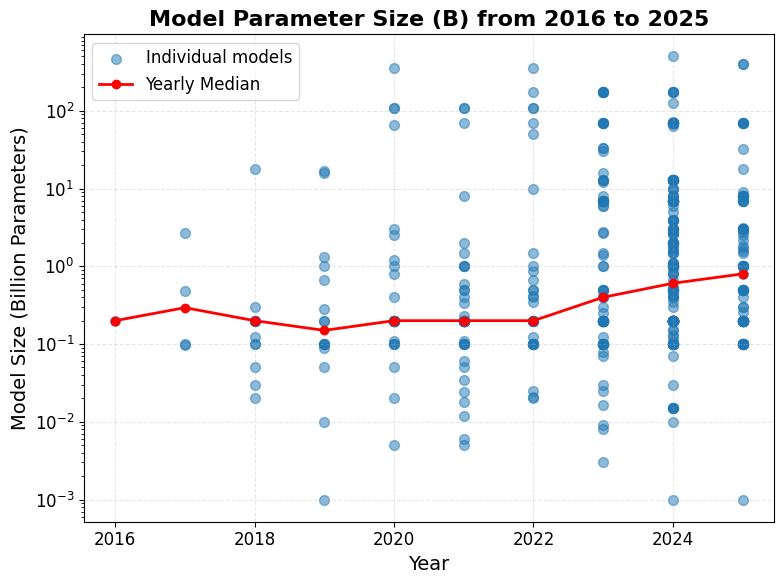

In [55]:
# Did our definition of small (in terms of model parameter size) change over time?
df_plot = df.explode("model_sizes").reset_index(drop=True)
df_plot = df_plot[df_plot["model_sizes"].notna()].copy()
df_plot["model_sizes"] = pd.to_numeric(df_plot["model_sizes"])

yearly_median = df_plot.groupby("year")["model_sizes"].median().reset_index()
yearly_avg = df_plot.groupby("year")["model_sizes"].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    df_plot["year"], df_plot["model_sizes"], alpha=0.5, s=50, label="Individual models"
)
ax.plot(
    yearly_median["year"],
    yearly_median["model_sizes"],
    color="red",
    linewidth=2,
    marker="o",
    label="Yearly Median",
)
# ax.plot(
#    yearly_avg["year"],
#    yearly_avg["model_sizes"],
#    color="blue",
#    linewidth=2,
#    marker="o",
#    label="Yearly Average",
# )

ax.set_xlabel("Year")
ax.set_ylabel("Model Size (Billion Parameters)")
ax.set_title("Model Parameter Size (B) from 2016 to 2025", fontweight="bold")
ax.grid(True, alpha=0.3, linestyle="--")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()

**Research Question**: Is efficient NLP still English-centric?

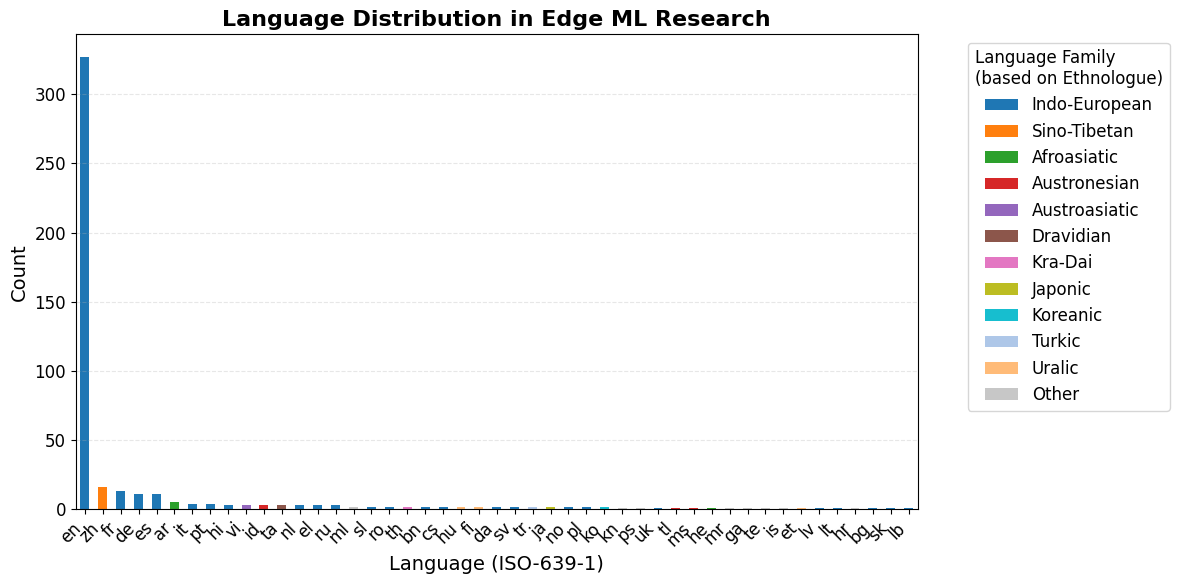

In [48]:
# Is edge ML work English-centric?
import langcodes

df_lang = df.explode("languages_supported").reset_index(drop=True)
df_lang = df_lang[df_lang["languages_supported"].notna()].copy()

programming_languages = {"C++", "Java", "Python", "JavaScript", "C#", "Ruby", "Go"}


def is_valid_language(code):
    if code in programming_languages:
        return False
    try:
        langcodes.Language.get(code)
        return True
    except:
        return False


def get_language_family(code):
    try:
        # fmt: off
        if code in ["en", "de", "fr", "es", "it", "pt", "ru", "hi", "bn", "fa", "el", "pl", "cs", "sv", "no", "da", "nl", "ro", "uk", "bg", "sr", "sl", "sk", "lb", "lt", "lv"]:
            return "Indo-European"
        # fmt: on
        elif code in ["zh"]:
            return "Sino-Tibetan"
        elif code in ["ar", "he"]:
            return "Afroasiatic"
        elif code in ["ja"]:
            return "Japonic"
        elif code in ["ko"]:
            return "Koreanic"
        elif code in ["tr"]:
            return "Turkic"
        elif code in ["fi", "et", "hu"]:
            return "Uralic"
        elif code in ["id", "ms", "tl"]:
            return "Austronesian"
        elif code in ["vi"]:
            return "Austroasiatic"
        elif code in ["ta"]:
            return "Dravidian"
        elif code in ["th"]:
            return "Kra-Dai"
        elif code in ["sw"]:
            return "Niger-Congo"
        else:
            return "Other"
    except:
        return "Other"


df_lang = df_lang[df_lang["languages_supported"].apply(is_valid_language)]
df_lang["language_family"] = df_lang["languages_supported"].apply(get_language_family)
lang_counts = df_lang["languages_supported"].value_counts()

family_colors = {
    "Indo-European": "#1f77b4",
    "Sino-Tibetan": "#ff7f0e",
    "Afroasiatic": "#2ca02c",
    "Austronesian": "#d62728",
    "Austroasiatic": "#9467bd",
    "Dravidian": "#8c564b",
    "Kra-Dai": "#e377c2",
    "Niger-Congo": "#7f7f7f",
    "Japonic": "#bcbd22",
    "Koreanic": "#17becf",
    "Turkic": "#aec7e8",
    "Uralic": "#ffbb78",
    "Other": "#c7c7c7",
}

colors = [family_colors[get_language_family(lang)] for lang in lang_counts.index]

fig, ax = plt.subplots(figsize=(12, 6))
lang_counts.plot(kind="bar", ax=ax, color=colors)
ax.set_xlabel("Language (ISO-639-1)")
ax.set_ylabel("Count")
ax.set_title("Language Distribution in Edge ML Research", fontweight="bold")
ax.grid(True, alpha=0.3, linestyle="--", axis="y")
plt.xticks(rotation=45, ha="right")

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=color, label=family)
    for family, color in family_colors.items()
    if any(get_language_family(lang) == family for lang in lang_counts.index)
]
ax.legend(
    handles=legend_elements,
    title="Language Family\n(based on Ethnologue)",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

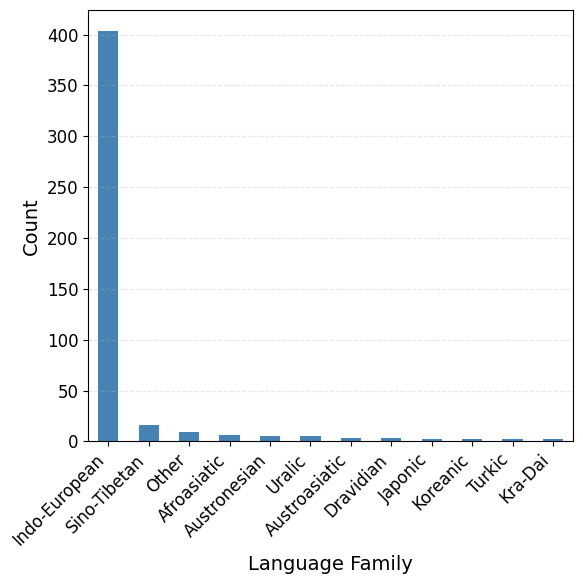

In [49]:
# Language family distribution
family_counts = df_lang["language_family"].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
family_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_xlabel("Language Family")
ax.set_ylabel("Count")
# ax.set_title("Language Family Distribution in Edge ML Research", fontweight="bold")
ax.grid(True, alpha=0.3, linestyle="--", axis="y")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Research Question:** How does the domain inform the deployment environment for edge ML models? Is there a relationship between where they are deployed (mobile devices, IoT, etc.) and the application domain (healthcare, finance, etc.)?

In [ ]:
import itertools

rows = []
for idx, row in df.iterrows():
    domains = row["application_domain"]
    platforms = row["deployment_platforms"]

    if domains is None or (isinstance(domains, float) and pd.isna(domains)):
        domains = []
    if platforms is None or (isinstance(platforms, float) and pd.isna(platforms)):
        platforms = []

    for domain, platform in itertools.product(domains, platforms):
        rows.append({"application_domain": domain, "deployment_platform": platform})

df_cross = pd.DataFrame(rows)
crosstab = pd.crosstab(df_cross["application_domain"], df_cross["deployment_platform"])
crosstab = crosstab.loc[crosstab.sum(axis=1).sort_values(ascending=False).index]
print(f"\nCross-tabulation shape: {crosstab.shape}")

Created 2331 domain-platform combinations

Cross-tabulation shape: (9, 6)
deployment_platform    Cloud  Laptop/PC  Microcontrollers  Mobile Devices  \
application_domain                                                          
Other                    452         69               127             483   
Healthcare               106         13                40             128   
Smart Cities              67          4                32              86   
Education                 66         11                20              78   
Industrial IoT            38          4                22              37   
Finance                   35          8                 8              32   
Legal                      9          3                 1               7   
Environmental Science      8          2                 1               5   
Agriculture                5          1                 2               5   

deployment_platform    Not Specified  Wearables  
application_domain          

Where are edgeML models being deployed and in which use-case?

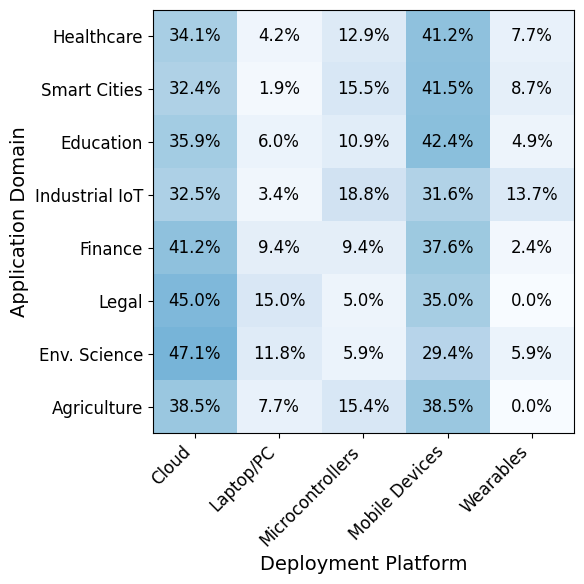

In [100]:
import numpy as np

crosstab_filtered = crosstab.copy()

if "Other" in crosstab_filtered.index:
    crosstab_filtered = crosstab_filtered.drop("Other", axis=0)
if "Not Specified" in crosstab_filtered.columns:
    crosstab_filtered = crosstab_filtered.drop("Not Specified", axis=1)
# if "Cloud" in crosstab_filtered.columns:
#    crosstab_filtered = crosstab_filtered.drop("Cloud", axis=1)
crosstab_filtered = crosstab_filtered.rename(
    index={"Environmental Science": "Env. Science"},
)

crosstab_pct = crosstab_filtered.div(crosstab_filtered.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(crosstab_pct.values, cmap="Blues", aspect="auto", vmin=0, vmax=100)
# cbar = plt.colorbar(im, ax=ax)
# cbar.set_label("Percentage (%)", rotation=270, labelpad=15)

for i in range(len(crosstab_pct.index)):
    for j in range(len(crosstab_pct.columns)):
        text = ax.text(
            j,
            i,
            f"{crosstab_pct.values[i, j]:.1f}%",
            ha="center",
            va="center",
            color="black",
            fontsize=12,
        )

ax.set_xticks(np.arange(len(crosstab_pct.columns)))
ax.set_yticks(np.arange(len(crosstab_pct.index)))
ax.set_xticklabels(crosstab_pct.columns, rotation=45, ha="right")
ax.set_yticklabels(crosstab_pct.index)
ax.set_xlabel("Deployment Platform")
ax.set_ylabel("Application Domain")
# ax.set_title("Application Domain vs. Deployment Platform (%)", fontweight="bold")

plt.tight_layout()
plt.show()

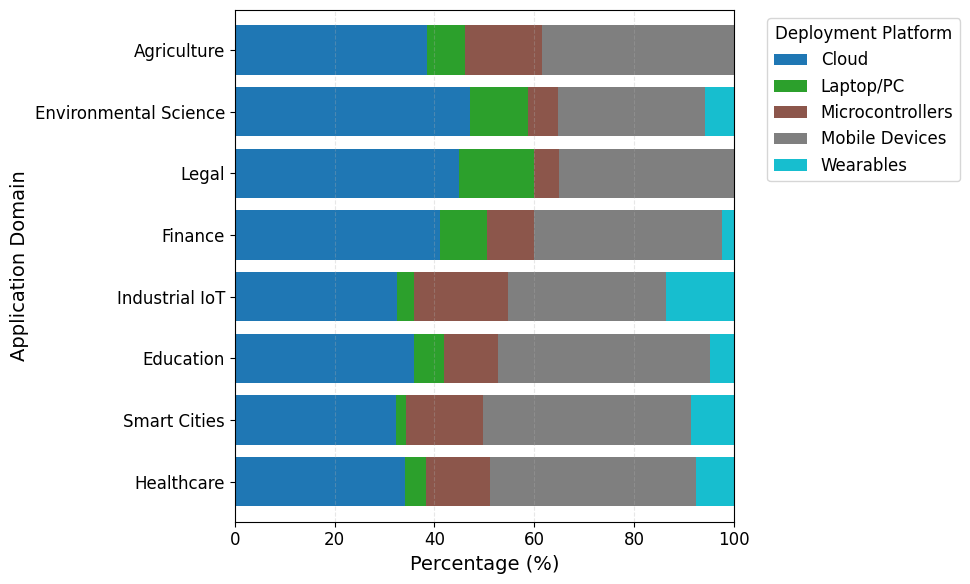

In [79]:
fig, ax = plt.subplots(figsize=(10, 6))

crosstab_pct.plot(kind="barh", stacked=True, ax=ax, colormap="tab10", width=0.8)
ax.set_xlabel("Percentage (%)")
ax.set_ylabel("Application Domain")
# ax.set_title("Deployment Platform Distribution by Application Domain", fontweight="bold")  # fmt: skip
ax.legend(title="Deployment Platform", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True, alpha=0.3, linestyle="--", axis="x")
ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

In [ ]:
def get_application_domains(application: str, deployment: str):
    deployment_df = df[
        df["deployment_platforms"].apply(lambda x: True if deployment in x else False)
    ].reset_index(drop=True)
    app_df = deployment_df[
        deployment_df["application_domain"].apply(
            lambda x: True if application in x else False
        )
    ].reset_index(drop=True)
    return app_df

In [139]:
for i in get_application_domains("Agriculture", "Cloud").sample(5).itertuples():
    print(f"- {i.title} ({i.year})")
    print(f"  URL: {i.s2_url}\n")
    print(f" {i.abstract}\n")

- Building A Natural Language Query And Control Interface For IoT Platforms (2022)
  URL: https://www.semanticscholar.org/paper/6e76587b7ca3e5e1761d8799014428e58d56edce

 The rapid development and popularity of IoT technology has reshaped the way people interact with the real world. Many researchers have attempted to build natural language interfaces for IoT platforms, but have not produced much progress in parsing natural language commands that contain multiple operations and more complex logical structures. In this paper, we propose IoT-NLI, a natural language query and control interface for popular IoT platforms, which uses hierarchical semantic parsing algorithms and directed edge-tagged graph structures to efficiently parse natural language commands input by users, enabling them to perform multiple operations contained in one complex natural language command. Experiments in three domains, agriculture, industry, and smart home, show that IoT-NLI has excellent performance and reason

In [126]:
get_application_domains("Environmental Science", "Cloud")

,s2_id,title,authors,abstract,publication_type,venue,date,year,is_open_access,open_access_pdf,...,subject_areas,application_domain,methods_used,deployment_platforms,models_released,model_sizes,modalities,languages_supported,relevance_score,relevance_reasoning
0,b186cb9c172a286aaf15e4f890c59b15140a10f1,Medicinal plant leaf information extraction us...,"[S. Prasad, P. Singh]",,[Conference],IEEE Region 10 Conference,2017-11-01,2017,False,,...,[Information Extraction],"[Healthcare, Environmental Science]","[Neural Architecture Search, Data-Efficient Tr...","[Mobile Devices, Cloud]",[],[],"[Text, Vision]",[],4,The paper addresses efficient information extr...
1,ef955355cd616a3799585e013df862387c2e190d,A Practical Mixed Precision Algorithm for Post...,"[N. Pandey, Markus Nagel, M. V. Baalen, Yin-Ru...",Neural network quantization is frequently used...,[JournalArticle],BMVC Workshop,2023-02-10,2023,True,http://arxiv.org/pdf/2302.05397,...,"[Generation, Language Modeling]","[Healthcare, Education, Finance, Agriculture, ...","[Quantization, Other]","[Mobile Devices, Cloud]",[],[],"[Text, Vision]",[],5,The paper presents a novel mixed-precision qua...
2,e617d35c5f6c795b6b8436d3d6d87986acdc47db,ChatGeoAI: Enabling Geospatial Analysis for Pu...,"[Ali Mansourian, Rachid Oucheikh]","Large Language Models (LLMs) such as GPT, BART...",[JournalArticle],ISPRS Int. J. Geo Inf.,2024-10-01,2024,False,,...,[Multimodality and Language Grounding to Visio...,[Environmental Science],"[Knowledge Distillation, Data-Efficient Training]",[Cloud],[Llama 2],[70.0],[Text],[en],4,The paper presents a novel framework using a l...
3,bee5d1a6302bb9f7c7395c82d8a9b4eabe056abb,Inf-MLLM: Efficient Streaming Inference of Mul...,"[Zhenyu Ning, Jieru Zhao, Qihao Jin, Wenchao D...",Multimodal Large Language Models (MLLMs) are d...,[JournalArticle],arXiv.org,2024-09-11,2024,False,,...,[Multimodality and Language Grounding to Visio...,"[Healthcare, Education, Finance, Agriculture, ...","[Efficient Architectures, Other]","[Mobile Devices, Laptop/PC, Cloud]",[Inf-MLLM],[0.1],[Multimodal],[],5,This paper introduces a novel framework for ef...
4,d4f00a848a20fafed7973ff0f7ba65927a6fc63a,Vision-Language Models for Edge Networks: A Co...,"[Ahmed Sharshar, Latif U. Khan, Waseem Ullah, ...",Vision large language models (VLMs) combine vi...,"[JournalArticle, Review]",IEEE Internet of Things Journal,2025-02-11,2025,False,,...,[Multimodality and Language Grounding to Visio...,"[Healthcare, Environmental Science, Other]","[Pruning, Quantization, Knowledge Distillation...","[Microcontrollers, Wearables, Mobile Devices, ...",[],[],"[Text, Vision, Multimodal]",[],5,The paper provides significant insights into o...
5,ad8b30bc3a314d3b3b9a2a3b298f29f03a809e59,Energy-Efficient AI over a Virtualized Cloud F...,"[B. Yosuf, S. Mohamed, Mohammed Moawad Alenazi...",Deep Neural Networks (DNNs) have served as a c...,"[JournalArticle, Book]",Energy-Efficient Computing and Networking,2021-05-07,2021,True,http://arxiv.org/pdf/2105.03221,...,[Multimodality and Language Grounding to Visio...,"[Environmental Science, Smart Cities, Industri...",[Other],"[Cloud, Not Specified]",[],[],"[Text, Speech, Vision]",[],4,The paper provides significant contributions t...
6,0572345cd64163f7e2507fec739d5577dd106504,An Accurate and Efficient Approach to Knowledg...,"[T. V. Ivanisenko, P. Demenkov, V. Ivanisenko]",The rapid growth of biomedical literature make...,[JournalArticle],International Journal of Molecular Sciences,2024-11-01,2024,False,,...,"[Information Extraction, Generation]","[Healthcare, Environmental Science]","[Knowledge Distillation, Efficient Architectures]","[Cloud, Laptop/PC, Mobile Devices]",[],[],[Text],[en],4,The paper provides significant contributions t...
7,4293a6ed1fe4b7c5874646d3928b9e8d6b067128,"Crisis Management in the Era of the IoT, Edge ...","[Dražen Ignjatović, Vasileios Karagiannis, Ara...",The Internet of Things (IoT) combined with edg...,"[JournalArticle, Conference]",2024 11th Inter